In [1]:
import os
import gc
import json
import random
import psutil
import ast
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DATA_DIR = Path("data")
MODEL_ID  = "HuggingFaceTB/SmolVLM-500M-Instruct"
IMG_SIZE  = 512
LOG_DIR   = Path("logs")
LOG_DIR.mkdir(exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB


In [2]:
train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df   = pd.read_csv(DATA_DIR / "val.csv")
test_df  = pd.read_csv(DATA_DIR / "test.csv")

for df in [train_df, val_df, test_df]:
    df["choices"] = df["choices"].apply(ast.literal_eval)

print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
print(f"Train with solution: {train_df['solution'].notna().sum()}/{len(train_df)}")
print(f"Val with solution:   {val_df['solution'].notna().sum()}/{len(val_df)}")

Train: 3,109 | Val: 1,048 | Test: 1,008
Train with solution: 2580/3109
Val with solution:   876/1048


In [3]:
def clean_solution(solution):
    """Extract clean rationale before the noisy Choice explanations."""
    if pd.isna(solution) or not solution:
        return None
    clean = solution.split('Choice "')[0].strip()
    return clean if clean else None

def build_stage1_prompt(row, include_answer=False, max_context_chars=2000):
    """Stage 1: Generate rationale from question + context + image."""
    text = ""
    if pd.notna(row.get("lecture", None)) and row["lecture"]:
        text += f"Background:\n{row['lecture'][:max_context_chars]}\n\n"
    if pd.notna(row.get("hint", None)) and row["hint"]:
        text += f"Passage:\n{row['hint'][:max_context_chars]}\n\n"

    text += f"Question: {row['question']}\n\n"
    text += "Choices:\n"
    for j, choice in enumerate(row["choices"]):
        text += f"  {chr(65+j)}. {choice}\n"

    last_letter = chr(65 + int(row["num_choices"]) - 1)
    text += f"\nThink step by step before answering (A to {last_letter})."

    prompt = f"<|im_start|>User:<image>{text}<end_of_utterance>\nAssistant:"

    if include_answer:
        rationale = clean_solution(row.get("solution", None))
        if rationale:
            prompt += f" {rationale} The answer is {chr(65 + int(row['answer']))}."
        else:
            prompt += f" The answer is {chr(65 + int(row['answer']))}."

    return prompt

def build_stage2_prompt(row, rationale, include_answer=False, max_context_chars=2000):
    """Stage 2: Predict answer given rationale."""
    text = ""
    if pd.notna(row.get("lecture", None)) and row["lecture"]:
        text += f"Background:\n{row['lecture'][:max_context_chars]}\n\n"
    if pd.notna(row.get("hint", None)) and row["hint"]:
        text += f"Passage:\n{row['hint'][:max_context_chars]}\n\n"

    text += f"Question: {row['question']}\n\n"
    text += "Choices:\n"
    for j, choice in enumerate(row["choices"]):
        text += f"  {chr(65+j)}. {choice}\n"

    last_letter = chr(65 + int(row["num_choices"]) - 1)
    text += f"\nReasoning: {rationale}\n"
    text += f"\nBased on the reasoning above, answer with a single letter (A to {last_letter})."

    prompt = f"<|im_start|>User:<image>{text}<end_of_utterance>\nAssistant:"

    if include_answer:
        prompt += f" {chr(65 + int(row['answer']))}"

    return prompt

def build_inference_prompt(row, rationale=None, max_context_chars=2000):
    """Inference prompt — with optional rationale for stage 2."""
    if rationale:
        return build_stage2_prompt(row, rationale, include_answer=False, max_context_chars=max_context_chars)
    return build_stage1_prompt(row, include_answer=False, max_context_chars=max_context_chars)

# Verify
sample = train_df[train_df['solution'].notna()].iloc[0]
print("=== Stage 1 training prompt ===")
print(build_stage1_prompt(sample, include_answer=True))
print()
print("=== Stage 2 training prompt ===")
rationale = clean_solution(sample['solution'])
print(build_stage2_prompt(sample, rationale, include_answer=True))

=== Stage 1 training prompt ===
<|im_start|>User:<image>Background:
Animals increase their reproductive success when they have offspring that survive to reproduce.
Animals can increase their chances of having offspring by behaving in ways that help them get partners to mate and reproduce with. These partners are called mates. For example, animals may make special sounds, perform specific dances, or show off bright colors to attract mates. Animals may also compete with each other for mates.
Animals can increase the chances that their offspring will survive to reproduce by caring for and protecting them. For example, animals may feed their offspring or guard them from predators. These behaviors increase the chances that the offspring will survive to adulthood, when they can reproduce.
Many behaviors can increase the chances that animals will have offspring that survive to reproduce. But the behaviors cannot guarantee that the animals will have greater reproductive success. Animals that a

In [4]:
from transformers import AutoProcessor

processor = AutoProcessor.from_pretrained(MODEL_ID)
if processor.tokenizer.pad_token is None:
    processor.tokenizer.pad_token = processor.tokenizer.eos_token

# Fix image processor settings
processor.image_processor.do_image_splitting = False
processor.image_processor.size = {"longest_edge": 512}
processor.image_processor.max_image_size = {"longest_edge": 512}

print(f"do_image_splitting: {processor.image_processor.do_image_splitting}")
print(f"size: {processor.image_processor.size}")

do_image_splitting: False
size: {'longest_edge': 512}


In [5]:
class Stage1Dataset(Dataset):
    """Train to generate rationale + answer."""
    def __init__(self, df, data_dir, img_size=512):
        # Only use samples with solutions
        self.df       = df[df['solution'].notna()].reset_index(drop=True)
        self.data_dir = data_dir
        self.img_size = img_size
        print(f"Stage1Dataset: {len(self.df)} samples with solutions")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(self.data_dir / row["image_path"]).convert("RGB")
        return {
            "image":  img,
            "text":   build_stage1_prompt(row, include_answer=True),
            "answer": int(row["answer"]),
        }

class Stage2Dataset(Dataset):
    """Train to predict answer given rationale."""
    def __init__(self, df, data_dir, img_size=512):
        self.df       = df[df['solution'].notna()].reset_index(drop=True)
        self.data_dir = data_dir
        self.img_size = img_size
        print(f"Stage2Dataset: {len(self.df)} samples with solutions")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img      = Image.open(self.data_dir / row["image_path"]).convert("RGB")
        rationale = clean_solution(row["solution"])
        return {
            "image":  img,
            "text":   build_stage2_prompt(row, rationale, include_answer=True),
            "answer": int(row["answer"]),
        }

class InferenceDataset(Dataset):
    """For val/test inference."""
    def __init__(self, df, data_dir, img_size=512):
        self.df       = df.reset_index(drop=True)
        self.data_dir = data_dir
        self.img_size = img_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(self.data_dir / row["image_path"]).convert("RGB")
        return {
            "image":   img,
            "row":     row,
            "answer":  int(row["answer"]) if "answer" in row else -1,
        }

train_s1_ds = Stage1Dataset(train_df, DATA_DIR)
train_s2_ds = Stage2Dataset(train_df, DATA_DIR)

print(f"\nStage 1 train: {len(train_s1_ds)}")
print(f"Stage 2 train: {len(train_s2_ds)}")

Stage1Dataset: 2580 samples with solutions
Stage2Dataset: 2580 samples with solutions

Stage 1 train: 2580
Stage 2 train: 2580


In [6]:
# Find assistant token ids for masking
assistant_token_ids = processor.tokenizer(
    "Assistant:", add_special_tokens=False
)["input_ids"]
print(f"'Assistant:' token ids: {assistant_token_ids}")

def collate_fn(batch):
    images  = [b["image"] for b in batch]
    texts   = [b["text"]  for b in batch]
    answers = [b["answer"] for b in batch]

    inputs = processor(
        text=texts,
        images=images,
        return_tensors="pt",
        padding=True,
    )

    labels = inputs["input_ids"].clone()
    labels[labels == processor.tokenizer.pad_token_id] = -100

    for i in range(labels.shape[0]):
        seq   = inputs["input_ids"][i].tolist()
        found = False
        for pos in range(len(seq) - len(assistant_token_ids)):
            if seq[pos:pos + len(assistant_token_ids)] == assistant_token_ids:
                labels[i, :pos + len(assistant_token_ids)] = -100
                found = True
                break
        if not found:
            labels[i, :] = -100

    inputs["labels"] = labels
    return inputs, torch.tensor(answers)

def score_choices(model, processor, image, prompt, choices):
    """Log-likelihood scoring for multiple choice."""
    scores = []
    for choice in choices:
        full_text = prompt + f" {choice}"
        inputs    = processor(
            text=[full_text], images=[image],
            return_tensors="pt", padding=True
        )
        inputs = {k: v.to(model.device) if torch.is_tensor(v) else v
                  for k, v in inputs.items()}
        with torch.no_grad():
            outputs = model(**inputs)
            logits  = outputs.logits

        shift_logits   = logits[:, :-1, :].contiguous()
        shift_labels   = inputs["input_ids"][:, 1:].contiguous()
        attention_mask = inputs["attention_mask"][:, 1:].contiguous()
        log_probs      = F.log_softmax(shift_logits, dim=-1)
        token_lp       = log_probs.gather(2, shift_labels.unsqueeze(-1)).squeeze(-1)
        token_lp       = token_lp * attention_mask
        score          = (token_lp.sum() / attention_mask.sum()).item()
        scores.append(score)

        del outputs, logits, shift_logits, shift_labels, log_probs, token_lp, inputs
        torch.cuda.empty_cache()

    return int(torch.tensor(scores).argmax().item())

def generate_rationale(model, processor, image, row, max_new_tokens=100):
    """Generate rationale for a single sample."""
    prompt = build_stage1_prompt(row, include_answer=False)
    inputs = processor(
        text=[prompt], images=[image],
        return_tensors="pt", padding=True
    )
    inputs = {k: v.to(model.device) if torch.is_tensor(v) else v
              for k, v in inputs.items()}
    with torch.no_grad():
        generated = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=processor.tokenizer.pad_token_id,
        )
    decoded  = processor.batch_decode(generated, skip_special_tokens=True)[0]
    # Extract only the generated part after "Assistant:"
    if "Assistant:" in decoded:
        rationale = decoded.split("Assistant:")[-1].strip()
    else:
        rationale = decoded.strip()
    del generated, inputs
    torch.cuda.empty_cache()
    return rationale

# Quick verify collate
sample_batch = [train_s1_ds[i] for i in range(2)]
inputs_test, answers_test = collate_fn(sample_batch)
for i in range(2):
    label_ids  = inputs_test["labels"][i]
    valid_mask = label_ids != -100
    valid_ids  = label_ids[valid_mask]
    decoded    = processor.tokenizer.decode(valid_ids)
    print(f"Sample {i+1} | answer={answers_test[i]} | trained on:\n'{decoded[:200]}'\n")

'Assistant:' token ids: [9519, 9531, 42]
Sample 1 | answer=2 | trained on:
' Look for the part of the passage that describes the effect of putting each tadpole in its own pool of water. Use this information to determine why this behavior can increase the reproductive success '

Sample 2 | answer=0 | trained on:
' Look for the part of the passage that describes the effect of forming strong social bonds with other females. Use this information to determine why this behavior can increase the reproductive success'



In [7]:
from transformers import AutoModelForVision2Seq, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

print("Loading base model...")
model = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="cuda:0",
    low_cpu_mem_usage=True,
)
model.config.use_cache = False

# LoRA config covering both text and vision
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=[
        # Text model
        "q_proj", "k_proj", "v_proj", "o_proj",
        # Vision model
        "model.vision_model.encoder.layers.*.self_attn.q_proj",
        "model.vision_model.encoder.layers.*.self_attn.k_proj",
        "model.vision_model.encoder.layers.*.self_attn.v_proj",
        "model.vision_model.encoder.layers.*.self_attn.out_proj",
    ],
    lora_dropout=0.05,
    bias="none",
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

ram  = psutil.virtual_memory()
vram = torch.cuda.memory_allocated() / 1e9
print(f"RAM:  {ram.used/1e9:.1f}/{ram.total/1e9:.1f} GB")
print(f"VRAM: {vram:.2f} GB")

Loading base model...


/home/rohan/pixels/venv/lib/python3.12/site-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(
/home/rohan/pixels/venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


trainable params: 4,161,536 || all params: 511,643,840 || trainable%: 0.8134
RAM:  6.7/16.7 GB
VRAM: 0.42 GB


In [8]:
from bitsandbytes.optim import PagedAdamW8bit
from transformers import get_cosine_schedule_with_warmup
from tqdm.notebook import tqdm

def train_stage(model, dataset, stage_name, epochs, lr, grad_accum,
                run_id, log, batch_size=4):
    print(f"\n{'='*60}")
    print(f"Training {stage_name}")
    print(f"{'='*60}")

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_fn,
        num_workers=0,
        pin_memory=False,
    )

    optimizer    = PagedAdamW8bit(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps  = (len(loader) // grad_accum) * epochs
    warmup_steps = max(1, int(total_steps * 0.03))
    scheduler    = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps,
    )

    global_step = 0
    model.train()

    for epoch in range(epochs):
        total_loss = 0
        optimizer.zero_grad()

        for step, (inputs, answers) in enumerate(tqdm(loader, desc=f"{stage_name} Epoch {epoch+1}")):
            inputs  = {k: v.to(model.device) if torch.is_tensor(v) else v
                       for k, v in inputs.items()}
            outputs = model(**inputs)
            loss    = outputs.loss / grad_accum
            loss.backward()
            total_loss += outputs.loss.item()

            log[f"{stage_name}_loss_per_step"].append({
                "step": global_step, "epoch": epoch+1,
                "loss": outputs.loss.item(),
            })

            del outputs, loss
            torch.cuda.empty_cache()

            if (step + 1) % grad_accum == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()
                global_step += 1

        avg_loss = total_loss / len(loader)
        log[f"{stage_name}_loss_per_epoch"].append(avg_loss)
        print(f"{stage_name} Epoch {epoch+1} | avg loss: {avg_loss:.4f}")

        # Save checkpoint
        ckpt_path = LOG_DIR / f"{stage_name}_epoch{epoch+1}_{run_id}"
        model.save_pretrained(ckpt_path)
        torch.save({
            "epoch": epoch+1,
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
        }, LOG_DIR / f"{stage_name}_trainer_state_epoch{epoch+1}_{run_id}.pt")
        print(f"Saved: {ckpt_path}")

        ram  = psutil.virtual_memory()
        vram = torch.cuda.memory_allocated() / 1e9
        print(f"RAM: {ram.used/1e9:.1f}/{ram.total/1e9:.1f} GB | VRAM: {vram:.2f} GB")

    del optimizer, scheduler, loader
    gc.collect()
    torch.cuda.empty_cache()
    return model

In [9]:
def evaluate(model, val_df, data_dir, n_samples=500, use_rationale=True, seed=42):
    """
    Two-stage evaluation:
    1. Generate rationale with stage 1 model
    2. Score choices conditioned on rationale
    """
    model.eval()
    subset  = val_df.sample(min(n_samples, len(val_df)), random_state=seed).reset_index(drop=True)
    correct = 0

    for idx in tqdm(range(len(subset)), desc="Val eval"):
        row   = subset.iloc[idx]
        image = Image.open(data_dir / row["image_path"]).convert("RGB")

        if use_rationale:
            # Stage 1: generate rationale
            rationale = generate_rationale(model, processor, image, row)
            # Stage 2: score choices with rationale
            prompt = build_stage2_prompt(row, rationale, include_answer=False)
        else:
            prompt = build_stage1_prompt(row, include_answer=False)

        pred = score_choices(model, processor, image, prompt, row["choices"])
        if pred == int(row["answer"]):
            correct += 1

    acc = correct / len(subset)
    print(f"Val accuracy ({n_samples} samples, rationale={use_rationale}): {acc:.4f}")
    model.train()
    return acc


Training stage1


stage1 Epoch 1:   0%|          | 0/645 [00:00<?, ?it/s]

stage1 Epoch 1 | avg loss: 0.6691
Saved: logs/stage1_epoch1_20260428_215205
RAM: 7.5/16.7 GB | VRAM: 0.49 GB


stage1 Epoch 2:   0%|          | 0/645 [00:00<?, ?it/s]

stage1 Epoch 2 | avg loss: 0.2691
Saved: logs/stage1_epoch2_20260428_215205
RAM: 7.6/16.7 GB | VRAM: 0.49 GB


...

stage2 Epoch 3:   0%|          | 0/645 [00:00<?, ?it/s]

stage2 Epoch 3 | avg loss: 0.0247
Saved: logs/stage2_epoch3_20260428_215205
RAM: 7.6/16.7 GB | VRAM: 0.49 GB

Evaluating after Stage 2 (with rationale)...


Val eval:   0%|          | 0/500 [00:00<?, ?it/s]

/home/rohan/pixels/venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Val accuracy (500 samples, rationale=True): 0.4220


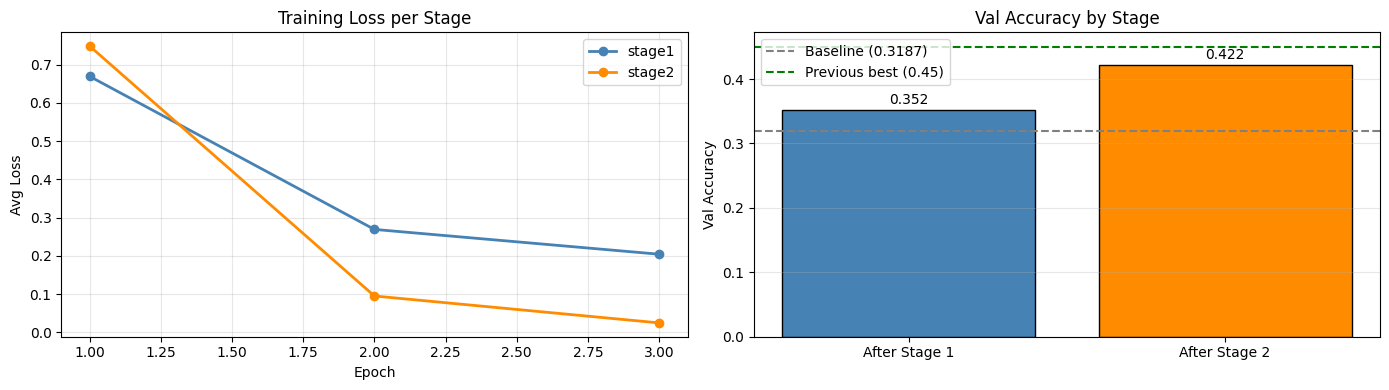


All logs saved to logs/twostage_log_20260428_215205.json
Stage 1 val accuracy: 0.3520
Stage 2 val accuracy: 0.4220


In [10]:
run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
log = {
    "run_id":                    run_id,
    "stage1_loss_per_step":      [],
    "stage1_loss_per_epoch":     [],
    "stage2_loss_per_step":      [],
    "stage2_loss_per_epoch":     [],
    "val_accuracy_after_stage1": [],
    "val_accuracy_after_stage2": [],
    "baseline_val_accuracy":     0.3187,
    "previous_best":             0.45,
}

# ── Stage 1: Train to generate rationale + answer ─────────────────────────────
model = train_stage(
    model       = model,
    dataset     = train_s1_ds,
    stage_name  = "stage1",
    epochs      = 3,
    lr          = 2e-4,
    grad_accum  = 4,
    run_id      = run_id,
    log         = log,
)

# Eval after stage 1 (without rationale — just direct answer)
print("\nEvaluating after Stage 1 (no rationale)...")
acc_s1 = evaluate(model, val_df, DATA_DIR, n_samples=500,
                  use_rationale=False, seed=42)
log["val_accuracy_after_stage1"].append(acc_s1)

with open(LOG_DIR / f"twostage_log_{run_id}.json", "w") as f:
    json.dump(log, f, indent=2)

# ── Stage 2: Train to predict answer given rationale ─────────────────────────
model = train_stage(
    model       = model,
    dataset     = train_s2_ds,
    stage_name  = "stage2",
    epochs      = 3,
    lr          = 1e-4,  # lower LR for stage 2
    grad_accum  = 4,
    run_id      = run_id,
    log         = log,
)

# Eval after stage 2 (with rationale)
print("\nEvaluating after Stage 2 (with rationale)...")
acc_s2 = evaluate(model, val_df, DATA_DIR, n_samples=500,
                  use_rationale=True, seed=42)
log["val_accuracy_after_stage2"].append(acc_s2)

with open(LOG_DIR / f"twostage_log_{run_id}.json", "w") as f:
    json.dump(log, f, indent=2)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for stage, color in [("stage1", "steelblue"), ("stage2", "darkorange")]:
    losses = log[f"{stage}_loss_per_epoch"]
    axes[0].plot(range(1, len(losses)+1), losses,
                 marker="o", label=stage, color=color, linewidth=2)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Avg Loss")
axes[0].set_title("Training Loss per Stage")
axes[0].legend(); axes[0].grid(alpha=0.3)

accs = [acc_s1, acc_s2]
bars = axes[1].bar(["After Stage 1", "After Stage 2"], accs,
                   color=["steelblue", "darkorange"], edgecolor="black")
axes[1].axhline(y=0.3187, color="gray", linestyle="--", label="Baseline (0.3187)")
axes[1].axhline(y=0.45,   color="green", linestyle="--", label="Previous best (0.45)")
axes[1].set_ylabel("Val Accuracy")
axes[1].set_title("Val Accuracy by Stage")
axes[1].legend(); axes[1].grid(axis="y", alpha=0.3)
for bar, acc in zip(bars, accs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{acc:.3f}", ha="center", va="bottom")

plt.tight_layout()
plt.savefig(LOG_DIR / f"twostage_{run_id}.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nAll logs saved to logs/twostage_log_{run_id}.json")
print(f"Stage 1 val accuracy: {acc_s1:.4f}")
print(f"Stage 2 val accuracy: {acc_s2:.4f}")

In [11]:
# Run this after training to generate submission from best checkpoint
# Change STAGE and EPOCH to whichever checkpoint you want

from peft import PeftModel

STAGE = "stage2"   # "stage1" or "stage2"
EPOCH = 3
CKPT_PATH = LOG_DIR / f"{STAGE}_epoch{EPOCH}_{run_id}"

print(f"Loading checkpoint: {CKPT_PATH}")

# Reload base model
base = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="cuda:0",
    low_cpu_mem_usage=True,
)
base.config.use_cache = False
infer_model = PeftModel.from_pretrained(base, CKPT_PATH)
infer_model.eval()

test_results = []
for idx in tqdm(range(len(test_df))):
    row    = test_df.iloc[idx]
    image  = Image.open(DATA_DIR / row["image_path"]).convert("RGB")

    # Generate rationale first
    rationale = generate_rationale(infer_model, processor, image, row)

    # Score choices with rationale
    prompt = build_stage2_prompt(row, rationale, include_answer=False)
    pred   = score_choices(infer_model, processor, image, prompt, row["choices"])
    test_results.append({"id": row["id"], "answer": pred})

submission_df = pd.DataFrame(test_results)
submission_df.to_csv(f"submission_{STAGE}_epoch{EPOCH}_{run_id}.csv", index=False)
print(f"Saved submission_{STAGE}_epoch{EPOCH}_{run_id}.csv")
print(submission_df.head())
print(f"Shape: {submission_df.shape}")

del infer_model, base
gc.collect()
torch.cuda.empty_cache()

Loading checkpoint: logs/stage2_epoch3_20260428_215205


  0%|          | 0/1008 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [12]:
print("Evaluating stage 2 checkpoint WITHOUT rationale...")
acc_no_rat = evaluate(model, val_df, DATA_DIR, n_samples=500,
                      use_rationale=False, seed=42)
print(f"Stage 2, no rationale: {acc_no_rat:.4f}")

Evaluating stage 2 checkpoint WITHOUT rationale...


Val eval:   0%|          | 0/500 [00:00<?, ?it/s]

Val accuracy (500 samples, rationale=False): 0.3880
Stage 2, no rationale: 0.3880


In [13]:
# ── Test NLI scoring on val set ───────────────────────────────────────────────
from tqdm.notebook import tqdm
import torch.nn.functional as F

# Get Yes/No token ids
yes_token = processor.tokenizer("Yes", add_special_tokens=False)["input_ids"][0]
no_token  = processor.tokenizer("No",  add_special_tokens=False)["input_ids"][0]
print(f"'Yes' token id: {yes_token}")
print(f"'No' token id:  {no_token}")

def score_choices_nli(model, processor, image, row, choices, max_context_chars=2000):
    scores = []
    for choice in choices:
        text = ""
        if pd.notna(row.get("lecture", None)) and row["lecture"]:
            text += f"Background:\n{row['lecture'][:max_context_chars]}\n\n"
        if pd.notna(row.get("hint", None)) and row["hint"]:
            text += f"Passage:\n{row['hint'][:max_context_chars]}\n\n"
        text += f"Question: {row['question']}\n"
        text += f"Proposed answer: {choice}\n"
        text += "Is this the correct answer? Yes or No."

        prompt = f"<|im_start|>User:<image>{text}<end_of_utterance>\nAssistant:"

        inputs = processor(text=[prompt], images=[image], return_tensors="pt", padding=True)
        inputs = {k: v.to(model.device) if torch.is_tensor(v) else v
                  for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)
            logits  = outputs.logits[:, -1, :]

        yes_score = logits[0, yes_token].item()
        no_score  = logits[0, no_token].item()
        scores.append(yes_score - no_score)

        del outputs, logits, inputs
        torch.cuda.empty_cache()

    return int(torch.tensor(scores).argmax().item())

# ── Run on 200 val samples ────────────────────────────────────────────────────
model.eval()
val_subset = val_df.sample(200, random_state=42).reset_index(drop=True)
correct = 0

for idx in tqdm(range(len(val_subset))):
    row    = val_subset.iloc[idx]
    image  = Image.open(DATA_DIR / row["image_path"]).convert("RGB")
    pred   = score_choices_nli(model, processor, image, row, row["choices"])
    if pred == int(row["answer"]):
        correct += 1

acc = correct / len(val_subset)
print(f"\nNLI scoring val accuracy (200 samples): {acc:.4f}")
print(f"Previous best: 0.45")
print(f"Difference: {acc - 0.45:+.4f}")

'Yes' token id: 10539
'No' token id:  5230


  0%|          | 0/200 [00:00<?, ?it/s]


NLI scoring val accuracy (200 samples): 0.5600
Previous best: 0.45
Difference: +0.1100


In [14]:
# ── Generate test submission with NLI scoring ─────────────────────────────────
model.eval()
test_results = []

for idx in tqdm(range(len(test_df))):
    row    = test_df.iloc[idx]
    image  = Image.open(DATA_DIR / row["image_path"]).convert("RGB")
    pred   = score_choices_nli(model, processor, image, row, row["choices"])
    test_results.append({"id": row["id"], "answer": pred})

submission_df = pd.DataFrame(test_results)
submission_df.to_csv("submission_nli.csv", index=False)
print(f"Saved submission_nli.csv")
print(submission_df.head())
print(f"Shape: {submission_df.shape}")

  0%|          | 0/1008 [00:00<?, ?it/s]

Saved submission_nli.csv
           id  answer
0  test_01750       2
1  test_00128       4
2  test_02891       4
3  test_02425       0
4  test_00930       3
Shape: (1008, 2)


In [15]:
# Check what a Yes/No training example looks like
sample = train_df.iloc[0]
print(f"num_choices: {sample['num_choices']}")
print(f"answer: {sample['answer']}")
print(f"choices: {sample['choices']}")
print()

# For each choice, show what the training prompt + target looks like
for j, choice in enumerate(sample['choices']):
    is_correct = (j == int(sample['answer']))
    target = "Yes" if is_correct else "No"
    
    text = ""
    if pd.notna(sample.get("lecture", None)) and sample["lecture"]:
        text += f"Background:\n{sample['lecture'][:2000]}\n\n"
    if pd.notna(sample.get("hint", None)) and sample["hint"]:
        text += f"Passage:\n{sample['hint'][:2000]}\n\n"
    text += f"Question: {sample['question']}\n"
    text += f"Proposed answer: {choice}\n"
    text += "Is this the correct answer? Yes or No."
    
    prompt = f"<|im_start|>User:<image>{text}<end_of_utterance>\nAssistant: {target}"
    print(f"Choice {chr(65+j)} ({'CORRECT' if is_correct else 'wrong'}): target='{target}'")
    print(f"Prompt length: {len(prompt)} chars")
    print()

num_choices: 3
answer: 2
choices: ["the male's tadpoles will be larger when they hatch", 'the male will carry his tadpoles through the forest', "the male's tadpoles will become adult frogs"]

Choice A (wrong): target='No'
Prompt length: 2500 chars

Choice B (wrong): target='No'
Prompt length: 2501 chars

Choice C (CORRECT): target='Yes'
Prompt length: 2494 chars

